# RNA fitness landscape analysis

In this tutorial, we’ll use GraphFLA to explore how mutations shape the activity of a catalytic RNA. To see how this works, we’ll build and analyse a complete landscape of ribozyme variants, then measure its ruggedness, epistasis and navigability.


## 1. Setting up

On Google Colab, the cell below installs GraphFLA. In any environment, it also downloads the dataset into a `data/` folder next to the notebook if the files are not already there.

We then import GraphFLA for landscape construction and analysis, pandas for working with the data, and NumPy and Matplotlib for plotting interactions.

In [1]:
import sys
from pathlib import Path
from urllib.request import urlretrieve

if "google.colab" in sys.modules:
    %pip install -q graphfla==0.4.0

DATA_URL = "https://raw.githubusercontent.com/COLA-Laboratory/GraphFLA/v0.4.0/tutorials/datasets/data/"
Path("data").mkdir(exist_ok=True)
for name in ["ribozyme.csv"]:
    if not Path("data", name).exists():
        urlretrieve(DATA_URL + name, Path("data", name))

In [2]:
from graphfla import analysis
from graphfla.landscape import RNALandscape
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


## 2. Loading the dataset

Ribozymes are RNA molecules that catalyse chemical reactions. [Bendixsen et al. (2019)](https://doi.org/10.1371/journal.pbio.3000300) studied sequences lying between two ribozymes with different functions: the self-cleaving hepatitis delta virus (HDV) ribozyme and a class III ligase ribozyme. Their reference sequences differ at 14 positions, and all combinations of the two nucleotides at each position give **2¹⁴ = 16,384 variants**. The authors measured both activities for **every variant**.

We’ll maximise ligase fitness, the change in a variant’s abundance after one round of selection for ligation, relative to the reference ligase ribozyme. The table also includes HDV fitness, the fraction of a variant that cleaves itself during transcription, relative to the reference HDV ribozyme. Both references have fitness 1.

| Column | Meaning |
|---|---|
| `sequence` | Nucleotides at the 14 variable positions; the rest of the ribozyme is fixed. |
| `ligase_fitness` | Ligase fitness relative to the reference ligase ribozyme. |
| `hdv_fitness` | HDV fitness relative to the reference HDV ribozyme. |

Let’s load the measurements:


In [3]:
df = pd.read_csv("data/ribozyme.csv", float_precision="round_trip")
df.head()


,sequence,ligase_fitness,hdv_fitness
0,AAUCGGCCUCACAG,0.015989,0.020744
1,CGUCGGCUCCGCAG,0.003735,0.000000
2,AGUCGUCUUUGGCG,0.007683,0.025124
3,AAGGCUCUCUACAC,0.033291,0.031116
4,CAGGCGGCUUACAC,0.008187,0.021991


## 3. Preparing the inputs

To construct a landscape, GraphFLA needs two aligned inputs:

- `X`: one row per configuration and one column per variable.
- `f`: one measured or calculated outcome for each row of `X`.

The sequence forms `X`. `RNALandscape` reads each sequence string as 14 positions with the alphabet A, C, G and U; in this library, each position carries one of two nucleotides.

Ligase fitness spans five orders of magnitude, from about 0.0002 to 19, and the 1% most active variants account for 99% of its variance. Like Bendixsen et al., who measured epistasis on a log₁₀ scale, we use log₁₀ ligase fitness as `f`, so that each mutation’s effect is a fold change. The transformation preserves which variant is fitter, so peaks and accessible paths are unchanged.

In [4]:
X = df["sequence"]
f = np.log10(df["ligase_fitness"])
X.head()


0    AAUCGGCCUCACAG
1    CGUCGGCUCCGCAG
2    AGUCGUCUUUGGCG
3    AAGGCUCUCUACAC
4    CAGGCGGCUUACAC
Name: sequence, dtype: object

## 4. Constructing the landscape

We can use `RNALandscape`, where neighbouring variants differ by a single nucleotide substitution. With two nucleotides per position, every variant has exactly 14 neighbours. We set `maximize=True` because higher ligase activity is better.


In [5]:
landscape = RNALandscape(maximize=True)
landscape.build_from_data(X, f, verbose=False)


RNALandscape(maximize=True)

## 5. Inspecting the landscape

Let’s first look at what we’ve built. Printing the landscape shows its variables, configurations, improving edges and local optima:


In [6]:
print(landscape)


RNALandscape(kind='rna'): 14 variables, 16384 configurations, 114682 edges, 68 local optima


For a closer look at individual variants, we can call `get_data()`. The 14 nucleotides appear as `pos_0` to `pos_13`; `out_degree` counts directly improving moves, and `is_lo` indicates local-optimum membership.


In [7]:
landscape.get_data().head()


,pos_0,pos_1,pos_2,pos_3,pos_4,pos_5,pos_6,pos_7,pos_8,pos_9,pos_10,pos_11,pos_12,pos_13,fitness,plateau_id,plateau_size,in_degree,out_degree,is_lo
0,A,A,U,C,G,G,C,C,U,C,A,C,A,G,-1.796177,-1,1,12,2,False
1,C,G,U,C,G,G,C,U,C,C,G,C,A,G,-2.427753,-1,1,4,10,False
2,A,G,U,C,G,U,C,U,U,U,G,G,C,G,-2.114477,-1,1,2,12,False
3,A,A,G,G,C,U,C,U,C,U,A,C,A,C,-1.477669,-1,1,11,3,False
4,C,A,G,G,C,G,G,C,U,U,A,C,A,C,-2.086855,-1,1,13,1,False


We can also summarise the log₁₀ fitness values with pandas:


In [8]:
landscape.get_data()["fitness"].describe()


count    16384.000000
mean        -2.149455
std          0.568825
min         -3.634333
25%         -2.481225
50%         -2.218275
75%         -1.828342
max          1.282743
Name: fitness, dtype: float64

On this scale, the reference ligase has fitness 0. Most variants are about a hundredfold less active, while 13 exceed the reference more than tenfold. To inspect the fittest variant, we can use the global-optimum node index:


In [9]:
landscape[landscape.go_index]


{'pos_0': 'A',
 'pos_1': 'G',
 'pos_2': 'G',
 'pos_3': 'G',
 'pos_4': 'C',
 'pos_5': 'G',
 'pos_6': 'C',
 'pos_7': 'C',
 'pos_8': 'U',
 'pos_9': 'U',
 'pos_10': 'G',
 'pos_11': 'C',
 'pos_12': 'C',
 'pos_13': 'G',
 'fitness': np.float64(1.282742555248472),
 'plateau_id': -1,
 'plateau_size': 1,
 'in_degree': 14,
 'out_degree': 0,
 'is_lo': True}

## 6. Analysing the landscape

Next, we’ll follow three questions in turn: how rugged the landscape is (6.1–6.2), which kinds of epistasis make it so (6.3–6.6), and whether evolution can still reach the best variant (6.7–6.8).


### 6.1 Number of local optima

We can start with `landscape.n_lo`. A local optimum, or fitness peak, is a variant without a fitter single-mutant neighbour; each connected neutral plateau of peaks counts once. Many peaks mean that adaptive walks, which accept only fitness-increasing mutations, can end at different variants.


In [10]:
print(f"Number of local optima: {landscape.n_lo}")


Number of local optima: 68


This matches the 68 peaks reported by Bendixsen et al. for the ligase landscape. The HDV activities define a second landscape over the same variants, and building it reproduces the authors’ count of 982 peaks:


In [11]:
hdv_landscape = RNALandscape(maximize=True).build_from_data(
    X, df["hdv_fitness"], verbose=False,
)
print(f"Number of local optima (HDV): {hdv_landscape.n_lo}")


Number of local optima (HDV): 982


The same sequences therefore form a much more rugged landscape for self-cleavage than for ligation. The rest of this tutorial analyses the ligase landscape.


### 6.2 Roughness-to-slope ratio

The peak count shows that the landscape is rugged, but not how far it departs from the simplest case. If every mutation had the same effect in every background, fitness would be additive and the landscape would have a single peak. The roughness-to-slope ratio, introduced by [Aita et al. (2000)](https://doi.org/10.1002/(SICI)1097-0282(200007)54:1%3C64::AID-BIP70%3E3.0.CO;2-R), measures this departure: it fits an additive model and compares the scatter left unexplained with the average size of the mutation effects. Values near zero indicate a nearly additive landscape; larger values indicate a more rugged one.

`r_s_ratio()` encodes each position relative to a reference nucleotide, so we compare values only when they are calculated in the same way.


In [12]:
roughness_to_slope = analysis.r_s_ratio(landscape)
print(f"Roughness-to-slope ratio: {roughness_to_slope:.4f}")


Roughness-to-slope ratio: 1.8698


### 6.3 Gamma star

Not every departure from additivity creates peaks. A mutation that is beneficial in every background still leads uphill; multiple peaks can arise only when mutation effects reverse direction between backgrounds, known as sign epistasis. [Ferretti et al. (2016)](https://doi.org/10.1016/j.jtbi.2016.01.037) proposed measuring epistasis by how well a mutation’s effect carries over when a second mutation is added to the background. `gamma_star()` applies this idea to the direction of effects only; we run it in a single process (`n_jobs=1`), which is fast enough here.

A value of 1 means mutations never switch between beneficial and deleterious; values near zero indicate frequent switches, and negative values indicate that pairs of mutations often reverse each other’s direction (reciprocal sign epistasis).


In [13]:
sign_correlation = analysis.gamma_star(landscape, n_jobs=1)
print(f"Gamma star: {sign_correlation:.4f}")


Gamma star: 0.3635


### 6.4 Idiosyncratic epistasis

Gamma star records only whether effects change direction. Even when the direction holds, the size of an effect can change from one background to another. [Lyons et al. (2020)](https://doi.org/10.1038/s41559-020-01286-y) introduced the idiosyncratic index to measure this variation: it compares the spread of a mutation’s effects across backgrounds with the fitness differences between randomly paired variants. A value of zero means each mutation has the same effect everywhere; a value near one means its effect varies about as much as the difference between two random variants.

`global_idiosyncratic_index()` averages this index over all mutations. Random pairs are drawn with a fixed seed.


In [14]:
idiosyncrasy = analysis.global_idiosyncratic_index(landscape, seed=42, n_jobs=1)
print(f"Global idiosyncratic index: {idiosyncrasy:.4f}")


Global idiosyncratic index: 0.3550


### 6.5 Walsh–Hadamard decomposition

Gamma star and the idiosyncratic index summarise epistasis across the whole landscape, but they do not show which positions are responsible. `walsh_hadamard()` helps locate it by describing fitness as a sum of single-mutation effects and interactions between pairs of positions, using the multistate extension of [Faure et al. (2024)](https://doi.org/10.1371/journal.pcbi.1012132). We stop at pairs, leaving higher-order interactions unresolved.

The library is complete, so the 106 pairwise-model coefficients are fitted to all 16,384 variants by ordinary least squares. Compare the first- and second-order training `r2`; `delta_r2` shows the extra variation explained by pairwise terms.


In [15]:
wh = analysis.walsh_hadamard(landscape, max_order=2)
wh["order_summary"]


,order,r2,delta_r2,rmse,n_terms,rank,alpha,model_variance_fraction,n_nonzero
0,0,0.000000,0.000000,0.568807,1,1,NaN,0.000000,<NA>
1,1,0.697772,0.697772,0.312703,15,15,NaN,0.817261,<NA>
2,2,0.853794,0.156022,0.217494,106,106,NaN,0.182739,<NA>


Which positions carry this variation? The helper functions below split the fitted model’s variance, taken over all possible combinations of nucleotides, into a share for each position (diagonal) and for each pair of positions (off-diagonal). The diagonal holds the additive part and the off-diagonal cells the pairwise part; each pair appears twice, and the diagonal plus one triangle add up to 100%. Unlike individual coefficients, these shares do not depend on the reference nucleotide. Positions are numbered 1 to 14 along the variable sites.

As a check, the pairwise shares add up to the order-2 `model_variance_fraction` in the table above.


In [16]:
def term_variance(block):
    """Variance of one fitted term over all allele combinations."""
    alleles = [
        part.str.extract(r"^(?P<ref>\w)_\d+_(?P<alt>\w)$")
        for _, part in block["term"].str.split("-", expand=True).items()
    ]
    states = [sorted({a["ref"].iloc[0], *a["alt"]}) for a in alleles]
    # Reference alleles keep a zero coefficient.
    effects = np.zeros([len(s) for s in states])
    for k, coefficient in enumerate(block["coefficient"]):
        cell = tuple(s.index(a["alt"].iloc[k]) for s, a in zip(states, alleles))
        effects[cell] = coefficient
    for axis in range(effects.ndim):
        effects = effects - effects.mean(axis=axis, keepdims=True)
    return np.mean(effects**2)


def variance_shares(coefficients, n_positions):
    """Share of fitted variance from each position (diagonal) and pair."""
    shares = np.zeros((n_positions, n_positions))
    for positions, block in coefficients.query("order > 0").groupby("positions"):
        i, j = positions[0] - 1, positions[-1] - 1
        shares[i, j] = shares[j, i] = term_variance(block)
    return shares / (np.trace(shares) + np.triu(shares, 1).sum())


def plot_shares(shares, labels):
    n = len(labels)
    size = min(0.55 * n, 6.0)
    percent = 100 * shares
    fig, ax = plt.subplots(figsize=(size + 2.4, size + 1.6))
    image = ax.imshow(percent, cmap="viridis")
    ax.set_xticks(range(n), labels, rotation=90 if n > 6 else 0)
    ax.set_yticks(range(n), labels)
    if n <= 9:
        midpoint = percent.max() / 2
        for (i, j), value in np.ndenumerate(percent):
            color = "black" if value > midpoint else "white"
            ax.text(j, i, f"{value:.1f}", ha="center", va="center",
                    fontsize=8, color=color)
    fig.colorbar(image, ax=ax, label="Share of fitted variance (%)")
    fig.tight_layout()
    plt.show()


Pairwise share of fitted variance: 0.183


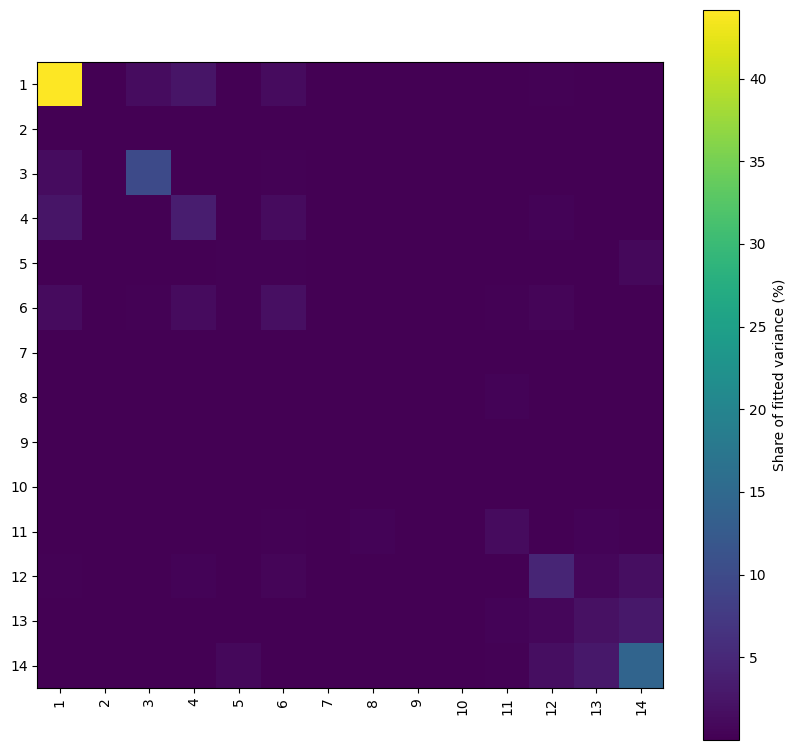

In [17]:
shares = variance_shares(wh["coefficients"], n_positions=14)
print(f"Pairwise share of fitted variance: {np.triu(shares, 1).sum():.3f}")
plot_shares(shares, labels=[str(i) for i in range(1, 15)])


### 6.6 Diminishing returns and increasing costs

Interactions between particular positions are one source of background dependence. Another is a general trend with how fit the background already is, known as global epistasis. Beneficial mutations can help less in fitter backgrounds, known as diminishing returns ([Chou et al., 2011](https://doi.org/10.1126/science.1203799)), while deleterious mutations can cost more, known as increasing costs ([Johnson et al., 2019](https://doi.org/10.1126/science.aay4199)).

`diminishing_returns_index()` correlates background fitness with the gain of each beneficial mutation; a negative value indicates diminishing returns. `increasing_costs_index()` correlates background fitness with the loss of each deleterious mutation; a positive value indicates increasing costs. Both pool all mutations together and depend on the fitness scale.


In [18]:
returns = analysis.diminishing_returns_index(landscape)
costs = analysis.increasing_costs_index(landscape)
print(f"Diminishing returns index: {returns:.4f}")
print(f"Increasing costs index: {costs:.4f}")


Diminishing returns index: -0.0225
Increasing costs index: 0.4797


### 6.7 Global optimum accessibility

Ruggedness and epistasis matter for evolution because peaks can trap adaptive walks. `global_optima_accessibility()` asks whether the fittest variant can still be reached: it returns the fraction of variants from which some path of fitness-increasing single mutations leads to the global optimum. A value of 1 means every variant has such a path; a small value means most adaptive walks must end at other peaks.


In [19]:
accessibility = analysis.global_optima_accessibility(landscape)
print(f"Global optimum accessibility: {accessibility:.4f}")


Global optimum accessibility: 0.9753


### 6.8 Fitness-distance correlation

Accessibility tells us whether an uphill path to the global optimum exists, not whether fitness points towards it. [Jones and Forrest (1995)](https://fluidinfo.com/research/fdc-abs.html) introduced fitness-distance correlation for this question. `fdc()` correlates each variant’s fitness with its number of mutations from the global optimum. A negative value means fitter variants tend to lie closer to the best variant; a value near zero means distance tells us little about fitness.


In [20]:
fitness_distance_r = analysis.fdc(landscape, method="spearman")
print(f"Fitness-distance correlation: {fitness_distance_r:.4f}")


Fitness-distance correlation: -0.4369


In summary, on the log scale the ligase landscape is largely additive: single positions account for 82% of the fitted variance, led by position 1 with 44%. Pairwise terms take the remaining 18%, spread thinly across many pairs; the largest, 13–14 and 1–4, contribute about 3% each. Sign epistasis still creates 68 peaks (γ* = 0.363), and deleterious mutations cost more in fitter backgrounds (0.480), whereas beneficial effects show almost no trend with background fitness (−0.022). The landscape is nonetheless easy to navigate: 97.5% of variants have a fitness-increasing path to the global optimum, and fitter variants tend to lie closer to it (FDC −0.437).


## 7. Running several analyses together

We can collect the single-value metrics above with `analysis.profile()`, using the same seed for the idiosyncratic index. `landscape.n_lo` supplies the peak count directly; the W–H result keeps its separate coefficient and order-summary tables.


In [21]:
analysis.profile(
    landscape,
    metrics=[
        "r_s_ratio", "gamma_star", "global_idiosyncratic_index",
        "diminishing_returns_index", "increasing_costs_index",
        "global_optima_accessibility", "fdc",
    ],
    seed=42, n_jobs=1, progress=False,
)


r_s_ratio                      1.869789
gamma_star                     0.363496
global_idiosyncratic_index     0.355042
diminishing_returns_index     -0.022482
increasing_costs_index         0.479708
global_optima_accessibility    0.975342
fdc                           -0.436932
dtype: float64

## 8. Analysis reference

For further exploration, `analysis.list_metrics()` lists the metrics available to `profile()`. The worked W–H result also exposes `fit_info`; its order summary separates cumulative training fit from the fitted model’s variance spectrum.

### Data sources

Bendixsen D. P. et al. (2019). [Genotype network intersections promote evolutionary innovation](https://doi.org/10.1371/journal.pbio.3000300). We use the genotype and fitness values in S1 Data (CC BY 4.0), writing sequences with U in place of T.